In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset

import shap 
import json

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.mps.is_available(): device = torch.device("mps")
device

/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='mps')

In [2]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)
#forward_fill_imputation(ts_data) 

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

full_dataset = NephroCAGEDataset(static_df=static_df, ts_data=ts_data, notes_df=notes, biopsy_df=dfs['biopsy'])
datapoints_limit = len(full_dataset)
#datapoints_limit = 5 
dataset = Subset(full_dataset, indices=list(range(datapoints_limit)))
ts_scaler = full_dataset.ts_scaler
static_scaler = full_dataset.scaler

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9


In [3]:
# Split dataset into training and test sets (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
print(test_size)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

677


In [8]:
class MultiModal_callable(nn.Module):
    def __init__(self, lstm_encoder, clf_model, categorical_cardinalities=None, use_static=False, use_notes=False, shapes=None):
        super(MultiModal_callable, self).__init__()
        self.use_static = use_static
        self.use_notes = use_notes
        self.shapes = shapes
        self.lstm_encoder = lstm_encoder
        self.clf_model = clf_model
        if use_static:
            assert(categorical_cardinalities is not None)
            self.static_encoder = StaticEncoder(categorical_cardinalities)
            self.static_fusion_layer = nn.Linear(CONFIG['lstm_hidden_size'] + CONFIG['static_output_dim'], CONFIG['lstm_hidden_size'])

        if use_notes:
            self.downproj = nn.Linear(CONFIG['notes_embedding_dim'], CONFIG['lstm_hidden_size'])
            self.cross_attention = nn.MultiheadAttention(embed_dim=CONFIG['lstm_hidden_size'], num_heads=CONFIG['num_heads'], batch_first=True)
            self.layer_norm = nn.LayerNorm(CONFIG['lstm_hidden_size'])

        self.ff = nn.Linear(CONFIG['lstm_hidden_size'], len(CONFIG['ts_features']))

    def forward(self, x):
        """
        In this version we change x to be a collection of all the input data as seen above, after we unpack it 
        in here this version should work exactly the same, but becomes compliante with libraries that expect 
        to be able to call model(data).
        """
        #Need shapes to unpack
        #shapes = [[19, 16], [19], [19], [226, 1024], [226],[6],[9],[19],[226]]
        sizes = [int(torch.prod(torch.tensor(s))) for s in self.shapes]
        chunks = torch.split(x, sizes, dim=-1)
        dtypes = [
                torch.float32,
                torch.float32,
                torch.long,
                torch.float32,
                torch.long,
                torch.long,
                torch.float32,
                torch.bool,
                torch.bool,
            ]

        unpacked = [
            chunk.view(*chunk.shape[:-1], *shape).to(dtype).to(device)
            for chunk, shape, dtype in zip(chunks, self.shapes, dtypes)
            ]
        ts, elapsed_times, timesteps, notes_embeddings, notes_timesteps, static_cat, static_features, mask, notes_mask = unpacked
        #print(x)
        lstm_out, attn_weights = self.lstm_encoder(ts, elapsed_times, mask)  # lstm_out: (batch_size, seq_length, lstm_hidden_size)
        
        assert not torch.isnan(lstm_out).any(), "NaN detected in LSTM output"

        static_encoding = None
        if self.use_static:
            assert(static_features is not None)
            static_encoding = self.static_encoder(static_cat, static_features)  # shape (batch_size, static output dim)
            # fuse static encoding into hidden states
            expanded_static = static_encoding.unsqueeze(1).repeat(1, lstm_out.shape[1], 1)  # expand static encoding to shape (bs, seq len, static output dim)
            fused_input = torch.cat([lstm_out, expanded_static], dim=-1)
            fused_output = self.static_fusion_layer(fused_input)  # shape (B, T, hidden_size)

            # Skip connection + activation
            lstm_out = torch_F.relu(fused_output + lstm_out)

            #lstm_out = torch.cat([lstm_out, expanded_static], dim=-1)  # shape (batch_size, seq_length, lstm_hidden_size + static output dim)
            #lstm_out = F.relu(self.static_fusion_layer(lstm_out)) # project back to (batch_size, seq_length, lstm_hidden_size)

        attn_weights_notes = None
        if self.use_notes:
            assert(notes_embeddings is not None)
            assert not torch.isnan(notes_embeddings).any(), "NaN detected in notes embeddings"
            # downprojection of notes to match lstm hidden size
            notes_embeddings = torch_F.relu(self.downproj(notes_embeddings))

            padding_notes_mask = None
            if notes_mask is not None:
                # For MultiheadAttention, key_padding_mask is (B, S) with True=ignore
                padding_notes_mask = ~notes_mask.bool()

            attn_mask = None
            if timesteps is not None and notes_timesteps is not None:
                # timesteps => (B, L)
                # notes_timesteps => (B, S)
                B, L = timesteps.shape
                _, S = notes_timesteps.shape
                t_i = timesteps.unsqueeze(-1)          # (B, L, 1)
                t_notes = notes_timesteps.unsqueeze(1) # (B, 1, S)
                # True => block => note is strictly in future
                base_mask = (t_notes > t_i)           # (B, L, S)

                # (optional) fix fully-blocked rows
                for b in range(B):
                    for l in range(L):
                        if base_mask[b, l].all():
                            # if you do not want to produce all-blocked => unmask them:
                            base_mask[b, l] = False

                # We must expand to (B*num_heads, L, S)
                num_heads = self.cross_attention.num_heads
                base_mask_4d = base_mask.unsqueeze(1).repeat(1, num_heads, 1, 1)  # (B, num_heads, L, S)
                attn_mask = base_mask_4d.view(B * num_heads, L, S)               # (B*num_heads, L, S)


            # Let the time steps attend to the notes (only up to the same-time notes)
            # let the time series embeddings attend to the texts 
            attn_output, attn_weights_notes = self.cross_attention(
                query=lstm_out,  # hidden states from LSTM for each timestep
                key=notes_embeddings,  # notes_embeddings for different timesteps
                value=notes_embeddings,
                attn_mask=None,
                key_padding_mask=padding_notes_mask,
                is_causal=False # Not strictly causal for cross-attention
            )
            lstm_out = self.layer_norm(lstm_out + attn_output)

        outputs = self.ff(lstm_out)  # (batch_size, seq_length, input_size)

        final_h = lstm_out[:, -1, :]
        logits = self.clf_model(final_h)
        #print(logits)

        return logits.unsqueeze(0) #outputs, lstm_out, (attn_weights, attn_weights_notes), static_encoding
    def set_shapes(self, shapes):
        self.shapes = shapes

In [9]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # 1 output for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.squeeze(-1)

In [19]:
task = "GraftLoss"
clf_model = SimpleMLP(input_dim=512)
clf_model.load_state_dict(torch.load(f"../models/{task}@90_clf.pth", weights_only=True))
clf_model.eval()
clf_model.to(device)

SimpleMLP(
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [11]:
#vanilla_lstm = VanillaTimeSeriesEncoder()
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModal_callable(att_encoder, clf_model, categorical_cardinalities=full_dataset.categorical_cardinalities, use_static=True, use_notes=True, shapes=None).to(device)

state_dict = torch.load('../models/after10epochs.pt', weights_only=True, map_location=torch.device(device))
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing:", missing)
print("Unexpected:", unexpected)

model.eval()
model.to(device)

Missing: ['lstm_encoder.lstm.lstm_cells.0.W_decomp', 'lstm_encoder.lstm.lstm_cells.0.b_decomp', 'lstm_encoder.lstm.lstm_cells.0.Wi', 'lstm_encoder.lstm.lstm_cells.0.Ui', 'lstm_encoder.lstm.lstm_cells.0.bi', 'lstm_encoder.lstm.lstm_cells.0.Wf', 'lstm_encoder.lstm.lstm_cells.0.Uf', 'lstm_encoder.lstm.lstm_cells.0.bf', 'lstm_encoder.lstm.lstm_cells.0.Wo', 'lstm_encoder.lstm.lstm_cells.0.Uo', 'lstm_encoder.lstm.lstm_cells.0.bo', 'lstm_encoder.lstm.lstm_cells.0.Wc', 'lstm_encoder.lstm.lstm_cells.0.Uc', 'lstm_encoder.lstm.lstm_cells.0.bc', 'lstm_encoder.lstm.lstm_cells.1.W_decomp', 'lstm_encoder.lstm.lstm_cells.1.b_decomp', 'lstm_encoder.lstm.lstm_cells.1.Wi', 'lstm_encoder.lstm.lstm_cells.1.Ui', 'lstm_encoder.lstm.lstm_cells.1.bi', 'lstm_encoder.lstm.lstm_cells.1.Wf', 'lstm_encoder.lstm.lstm_cells.1.Uf', 'lstm_encoder.lstm.lstm_cells.1.bf', 'lstm_encoder.lstm.lstm_cells.1.Wo', 'lstm_encoder.lstm.lstm_cells.1.Uo', 'lstm_encoder.lstm.lstm_cells.1.bo', 'lstm_encoder.lstm.lstm_cells.1.Wc', 'lst

MultiModal_callable(
  (lstm_encoder): TimeAwareAttentionEncoder(
    (lstm): TimeAwareLSTM(
      (lstm_cells): ModuleList(
        (0-1): 2 x TLSTMCell()
      )
    )
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (layer_norm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=512, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=512, bias=True)
    )
    (layer_norm_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (clf_model): SimpleMLP(
    (fc1): Linear(in_features=512, out_features=128, bias=True)
    (relu): ReLU()
    (fc2): Linear(in_features=128, out_features=1, bias=True)
  )
  (static_encoder): StaticEncoder(
    (embeddings): ModuleList(
      (0): Embedding(2, 16)
      (1): Embedding(491, 16)
      (2): Embedding(9, 16)
      (3): Embedding(2, 16)
      (4)

In [13]:
num_cat   = len(CONFIG['static_categorical_cols'])
num_num   = len(CONFIG['static_numerical_cols'])
F         = len(CONFIG['ts_features'])
T_max     = 20           # total padded sequence length
predict_steps_ahead = 1
T_eff = T_max - predict_steps_ahead
if T_eff <= 0:
    raise ValueError(f"T_eff={T_eff} must be > 0. Check T_max vs predict_steps_ahead.")
CONFIG['max_notes'] = 100


In [14]:
def pipeline_predict(static_cat, static_num, ts_feats, timesteps, mask, notes_embeddings, notes_timesteps, notes_mask, m=None):
    """
    Runs a forward pass (model -> clf_model). 
    Returns shape (B,) with probabilities.
    """
    print("initiate pipeline")
    B = static_cat.size(0)
    if m is not None:
        model = m
    #print(f"replaced model with {m}")
    # Ensure the data is on the right device
    static_cat = static_cat.to(device)
    static_num = static_num.to(device)
    ts_feats   = ts_feats.to(device)
    timesteps  = timesteps.to(device)
    mask       = mask.to(device)

    notes_embeddings = notes_embeddings.to(device)
    notes_timesteps = notes_timesteps.to(device)
    notes_mask = notes_mask.to(device)

    # Make sure the feature dimensions are correct
    ts_feats = ts_feats[:, :T_eff, :]
    timesteps = timesteps[:, :T_eff]
    mask = mask[:, :T_eff]
    print("build intervals")
    if T_eff > 1:
        intervals = timesteps[:, 1:] - timesteps[:, :-1]
    else:
        intervals = torch.zeros((B, 0), device=device)

    dummy_col = torch.zeros((B, 1), device=device, dtype=intervals.dtype)
    elapsed_times = torch.cat([intervals, dummy_col], dim=1)
    print(f"call model for time {elapsed_times.shape}")
    print(f"with the following data {ts_feats.shape}")
    pred_ts, lstm_out, attn, static_encoding = model(
        x=ts_feats,
        elapsed_times=elapsed_times,
        timesteps=timesteps,
        static_features=(static_cat, static_num),
        mask=mask,
        notes_embeddings=notes_embeddings,
        notes_timesteps=notes_timesteps,
        notes_mask=notes_mask
    )
    print(f"got pred_ts: {pred_ts}, lstm output: {lstm_out}, attn: {attn}, static_encoding: {static_encoding}")
    final_h = lstm_out[:, -1, :]
    logits = clf_model(final_h)
    print(f"logits: {logits}")
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    return pred_ts, lstm_out, attn, static_encoding#, probs

@torch.no_grad()
def pipeline_predict_flat(flat_data, model=None):
    """
    SHAP-compatible prediction function that handles flattened input data.
    """
    B = flat_data.shape[0]
    sc_list, sn_list, tf_list = [], [], []
    nt_list, nt_timesteps_list, nt_mask_list = [], [], []
    
    for i in range(B):
        sc_i, sn_i, tf_i, nt_i, nt_timesteps_i, nt_mask_i = unflatten_sample_only_feats(flat_data[i])
        sc_list.append(sc_i)
        sn_list.append(sn_i)
        tf_list.append(tf_i)
        nt_list.append(nt_i)
        nt_timesteps_list.append(nt_timesteps_i)
        nt_mask_list.append(nt_mask_i)
    
    # Concatenate batches
    sc_batch = torch.cat(sc_list, dim=0)
    sn_batch = torch.cat(sn_list, dim=0)
    tf_batch = torch.cat(tf_list, dim=0)
    nt_batch = torch.cat(nt_list, dim=0)
    nt_timesteps_batch = torch.cat(nt_timesteps_list, dim=0)
    nt_mask_batch = torch.cat(nt_mask_list, dim=0)
    
    # Create fixed timesteps and mask for time series
    fixed_tm = torch.arange(T_eff, device=device).unsqueeze(0).repeat(B, 1)
    fixed_mk = torch.ones((B, T_eff), device=device, dtype=torch.bool)
    return pipeline_predict(
        sc_batch, sn_batch, tf_batch, fixed_tm, fixed_mk,
        nt_batch, nt_timesteps_batch, nt_mask_batch, model
    )

def get_expected_feature_size():
    """Calculate the expected feature vector size."""
    return (
        num_cat +  # static categorical
        num_num +  # static numerical 
        T_eff * F +  # time series
        1  # aggregated notes mean
    )

def flatten_sample_only_feats(sc, sn, tf, nt, nt_timesteps, nt_mask):
    """
    Flatten features with notes embeddings aggregated into a single feature.
    Ensures consistent dimensionality across samples.
    """
    # Convert to numpy arrays
    sc_np = sc.view(-1).cpu().numpy()
    sn_np = sn.view(-1).cpu().numpy()
    tf_np = tf[:, :T_eff, :].reshape(-1).cpu().numpy()
    
    # Calculate mean of notes embeddings where mask is True
    masked_notes = nt * nt_mask.unsqueeze(-1)  # Apply mask to embeddings
    notes_sum = masked_notes.sum(dim=1)  # Sum across notes
    mask_sum = nt_mask.sum(dim=1, keepdim=True).clamp(min=1)  # Avoid division by zero
    notes_mean = (notes_sum / mask_sum).mean(dim=1)  # Mean across embedding dimensions
        
    # Combine all features
    feature_vector = np.concatenate([
        sc_np,  # static categorical
        sn_np,  # static numerical
        tf_np,  # time series
        notes_mean.cpu().numpy(),  # aggregated notes
    ])
    
    expected_size = get_expected_feature_size()
    assert len(feature_vector) == expected_size, \
        f"Feature vector size {len(feature_vector)} doesn't match expected size {expected_size}"
    
    return feature_vector

def unflatten_sample_only_feats(flat_vec):
    """
    Rebuild features from flattened vector with aggregated notes.
    """
    flat_vec = flat_vec.numpy()
    expected_size = get_expected_feature_size()
    assert len(flat_vec) == expected_size, \
        f"Input vector size {len(flat_vec)} doesn't match expected size {expected_size}"
    
    offset = 0
    
    # Static categorical
    sc_size = num_cat
    sc_np = flat_vec[offset:offset + sc_size].reshape(1, num_cat)
    offset += sc_size
    
    # Static numerical
    sn_size = num_num
    sn_np = flat_vec[offset:offset + sn_size].reshape(1, num_num)
    offset += sn_size
    
    # Time series
    tf_size = T_eff * F
    tf_np = flat_vec[offset:offset + tf_size].reshape(1, T_eff, F)
    offset += tf_size
    
    # Notes embedding mean (expand to full size)
    notes_mean = flat_vec[offset]
    
    # Create dummy notes tensors
    nt_np = np.full((1, CONFIG['max_notes'], CONFIG['notes_embedding_dim']), notes_mean)
    nt_mask_np = np.ones((1, CONFIG['max_notes']))
    nt_timesteps_np = np.arange(CONFIG['max_notes']).reshape(1, -1)
    
    # Convert to tensors
    sc_t = torch.tensor(sc_np, dtype=torch.long, device=device)
    sn_t = torch.tensor(sn_np, dtype=torch.float32, device=device)
    tf_t = torch.tensor(tf_np, dtype=torch.float32, device=device)
    nt_t = torch.tensor(nt_np, dtype=torch.float32, device=device)
    nt_timesteps_t = torch.tensor(nt_timesteps_np, dtype=torch.float32, device=device)
    nt_mask_t = torch.tensor(nt_mask_np, dtype=torch.float32, device=device)
    
    return sc_t, sn_t, tf_t, nt_t, nt_timesteps_t, nt_mask_t

def run_analysis(test_dataloader, model, max_samples=5, ):
    """
    Run Something for multiple samples
    """
    sample_count = 0
    
    for batch in test_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            if sample_count >= max_samples:
                break

            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            
            sample_count += 1
            print(f"Processed sample {sample_count}/{max_samples}")
            
        if sample_count >= max_samples:
            break
            
    return    

def pack_tensors(*tensors):
    flat = [t.reshape(t.shape[0], -1).to(device) for t in tensors]
    return torch.cat(flat, dim=1)

def extract_sample(i):
    for batch in test_dataloader:
        sc = batch['static_categorical_features'][i:i+1]
        sn = batch['static_numerical_features'][i:i+1]
        tf = batch['ts_features'][i:i+1]
        t = batch['timesteps'][i:i+1]
        m = batch['mask'][i:i+1]
        nt = batch['notes_embeddings'][i:i+1]
        nt_timesteps = batch['notes_timesteps'][i:i+1]
        nt_mask = batch['notes_mask'][i:i+1]
        break
    B = sc.size(0)
    ts_feats = tf[:, :T_eff, :]
    timesteps = t[:, :T_eff]
    mask = m[:, :T_eff]
    if T_eff > 1:
        intervals = timesteps[:, 1:] - timesteps[:, :-1]
        intervals = intervals.to(device)
    else:
        intervals = torch.zeros((B, 0), device=device)

    dummy_col = torch.zeros((B, 1), device=device, dtype=intervals.dtype)
    elapsed_times = torch.cat([intervals, dummy_col], dim=1)
    shapes = [ts_feats.squeeze(0).shape, elapsed_times.squeeze(0).shape, timesteps.squeeze(0).shape, nt.squeeze(0).shape, nt_timesteps.squeeze(0).shape, sc.squeeze(0).shape, sn.squeeze(0).shape, mask.squeeze(0).shape, nt_mask.squeeze(0).shape]

    return pack_tensors(ts_feats, elapsed_times, timesteps, nt, nt_timesteps, sc, sn, mask, nt_mask), shapes

In [16]:
sample, shapes = extract_sample(0)
print(sample)
sample.requires_grad_(True)
print(f"shapes {shapes}")
model.set_shapes(shapes)

#for name, param in model.named_parameters():
#    print("param", name, param.device)
#probs = model(sample)

tensor([[-0.7072, -0.7046, -0.6946,  ...,  0.0000,  0.0000,  0.0000]],
       device='mps:0')
shapes [torch.Size([19, 16]), torch.Size([19]), torch.Size([19]), torch.Size([223, 1024]), torch.Size([223]), torch.Size([6]), torch.Size([9]), torch.Size([19]), torch.Size([223])]


In [18]:
# compute attribution heatmaps of a list of layers 
# and output ids of relevant concepts
from crp.concepts import ChannelConcept
from zennit.composites import EpsilonPlusFlat
from zennit.canonizers import SequentialMergeBatchNorm
from crp.helper import get_layer_names
from crp.attribution import CondAttribution

cc = ChannelConcept()
composite = EpsilonPlusFlat([SequentialMergeBatchNorm()])
attribution = CondAttribution(model=model, device = device, overwrite_data_grad=True, no_param_grad=False)

layer_names = get_layer_names(model, [torch.nn.Linear])
#print(layer_names[0:-2])
mask_map = {name: cc.mask for name in layer_names}
conditions = [{"y": [0]}] 
#conditions = [{"y": [0], "clf_model.fc1": [107]}] 

attr = attribution(sample, conditions, composite, mask_map=mask_map, record_layer=layer_names)

for LAYER in layer_names[1:-2]:
    #print(attr.activations[LAYER].shape, attr.relevances[LAYER].shape)
    #print(attr.activations.keys())
    rel_c = cc.attribute(attr.relevances[LAYER], abs_norm=True)
    #print(rel_c.shape)

    # the six most relevant concepts and their contribution to final classification in percent
    rel_values, concept_ids = torch.topk(rel_c[0], min(attr.activations[LAYER].shape[1], 5))
    print(f"{LAYER}, Most important Neurons: {concept_ids}, Relevance for activation:{rel_values*100}") #At least in LSTM seems to show most relevant timestep. 


lstm_encoder.ff.0, Most important Neurons: tensor([18,  0,  1,  2,  3], device='mps:0'), Relevance for activation:tensor([100.,   0.,   0.,   0.,   0.], device='mps:0')
lstm_encoder.ff.2, Most important Neurons: tensor([0, 1, 2, 3, 4], device='mps:0'), Relevance for activation:tensor([0., 0., 0., 0., 0.], device='mps:0')
clf_model.fc1, Most important Neurons: tensor([21, 18, 54, 67, 53], device='mps:0'), Relevance for activation:tensor([6.1557, 2.0111, 1.1783, 0.4966, 0.4656], device='mps:0')
clf_model.fc2, Most important Neurons: tensor([0], device='mps:0'), Relevance for activation:tensor([-100.], device='mps:0')
static_encoder.numerical_processor.0, Most important Neurons: tensor([ 8, 11,  7,  1,  6], device='mps:0'), Relevance for activation:tensor([8.1656, 1.3263, 0.4288, 0.1894, 0.0096], device='mps:0')
static_encoder.fc, Most important Neurons: tensor([177,  15,  36, 126, 203], device='mps:0'), Relevance for activation:tensor([5.2614, 3.9372, 3.0945, 3.0929, 2.8953], device='mps

In [ ]:
from crp.graph import trace_model_graph
from crp.graph import _collect_node_inputs_and_outputs
from crp.graph import _get_input_nodes
from crp.graph import ModelGraph
from crp.graph import _build_graph_recursive
from crp.graph import _find_overlap_with_output

# Manual rebuild of crp.grapg.tace_model_graph to remove parts of the funciton not compatible with our model

traced = torch.jit.trace(model, (sample,), check_trace=False)
    # inlined_graph returns a suitable presentation of the traced model
graph = traced.inlined_graph
node_inputs, node_outputs = _collect_node_inputs_and_outputs(graph)
input_nodes = _get_input_nodes(graph, node_inputs, node_outputs)
MG = ModelGraph(input_nodes)

    # start recursive decoding of torch.jit graph
for node in graph.nodes():
    #print(node.kind())
    if "aten" in node.kind():
        name = node.scopeName()
        #if name not in layer_names:
        #    continue
        x = node_inputs[name]
            # if its inputs are not ourputs of other modules -> an input node
        for j in node_outputs:
            y = node_outputs[j]
            if not set(x) & set(y):
                input_nodes.append(node)
            #else:
            #    print(set(x), set(y))


for node in input_nodes:
    print(node)
    _build_graph_recursive(MG, graph, node)
#graph = trace_model_graph(model, sample, layer_names=layer_names[-1::])
#print(graph)

In [ ]:
print(layer_names)
#MG.set_layer_names(layer_names[1:-1]) #set_layer_names always throws an exception 
print(MG)

['lstm_encoder.attention.out_proj', 'lstm_encoder.ff.0', 'lstm_encoder.ff.2', 'clf_model.fc1', 'clf_model.fc2', 'static_encoder.numerical_processor.0', 'static_encoder.fc', 'static_fusion_layer', 'downproj', 'cross_attention.out_proj', 'ff']
aten::split_with_sizes -> prim::ListUnpack, 
prim::ListUnpack -> aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__mo

In [ ]:
%%script false --no-raise-error
# Never got the AttributionGraph to work as the script runs absurdly long
# even on our gpu cluster
from crp.attribution import AttributionGraph

layer_map = {name: cc for name in layer_names}
attgraph = AttributionGraph(attribution, MG, layer_map)

# decompose concept 71 in features.40 w.r.t. target 46 (lizard class)
# width=[5, 2] returns first the 5 most relevant concepts in the previous lower-level layer
# and in the second iteration returns for each of the 5 most relevant concepts again the two
# most relevant concepts in the previous lower-level layer
nodes, connections = attgraph(sample, composite, 107, "clf_model.fc1", 0, width=[5, 2], abs_norm=True)
print("Nodes:\n", nodes, "\nConnections:\n", connections)

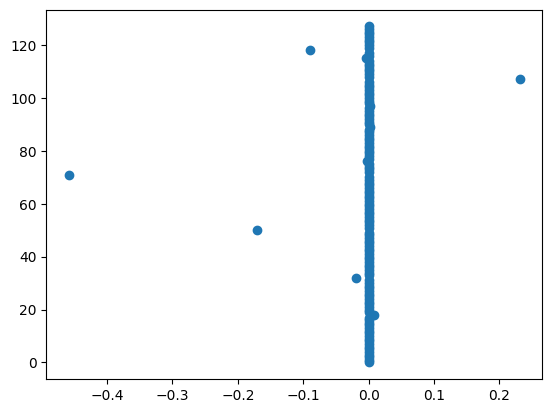

In [ ]:
#for i in range(0,10):
# Plots relevance of concepts encoded in a given layer
# E.g. on an lstm layer we can observe relevance of timesteps  
LAYER = "clf_model.fc1"
sample, shapes = extract_sample(0)
sample.requires_grad_(True)
model.set_shapes(shapes)
attr = attribution(sample, conditions, composite, mask_map=cc.mask, record_layer=layer_names)
rel_c = cc.attribute(attr.relevances[LAYER], abs_norm=True)
rel_values, concept_ids = torch.topk(rel_c[0], min(attr.activations[LAYER].shape[1], 200))
plt.scatter(rel_values, concept_ids)
#print(attr.activations[LAYER].shape, attr.relevances[LAYER].shape)
#print(attr.activations.keys())
#plt.show()

In [ ]:
from crp.visualization import FeatureVisualization
# TODO: use zennit to compute RelMax and find patients that best represent learned concepts
# Probably requieres intense reformatting of the library code, as it's only inteded for image data

In [ ]:
%%script false --no-raise-error
# Our models model graph generated by zennit
# as string output

aten::split_with_sizes -> prim::ListUnpack, 
prim::ListUnpack -> aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, aten::size, aten::view, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder/__module.lstm_encoder.layer_norm_1, 
__module.lstm_encoder/__module.lstm_encoder.layer_norm_1 -> __module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.0, __module.lstm_encoder, 
__module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.0 -> __module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.1, 
__module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.1 -> __module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.2, 
__module.lstm_encoder/__module.lstm_encoder.ff/__module.lstm_encoder.ff.2 -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder/__module.lstm_encoder.layer_norm_2, 
__module.lstm_encoder/__module.lstm_encoder.layer_norm_2 -> aten::size, prim::ListConstruct, aten::add, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::repeat, 
aten::repeat -> prim::ListConstruct, 
prim::ListConstruct -> aten::cat, 
aten::cat -> __module.static_fusion_layer, 
__module.static_fusion_layer -> aten::add, 
aten::add -> aten::relu, 
aten::relu -> __module.cross_attention, aten::add, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> aten::add, 
aten::add -> __module.layer_norm, 
__module.layer_norm -> aten::slice, 
aten::slice -> aten::select, 
aten::select -> aten::slice, 
aten::slice -> __module.clf_model/__module.clf_model.fc1, 
__module.clf_model/__module.clf_model.fc1 -> __module.clf_model/__module.clf_model.relu, 
__module.clf_model/__module.clf_model.relu -> __module.clf_model/__module.clf_model.fc2, 
__module.clf_model/__module.clf_model.fc2 -> __module.clf_model, 
__module.clf_model -> aten::unsqueeze, 
aten::unsqueeze ->  end__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, prim::TupleConstruct, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> prim::TupleConstruct, 
prim::TupleConstruct -> prim::TupleUnpack, 
prim::TupleUnpack -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm, 
__module.lstm_encoder/__module.lstm_encoder.lstm -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.0, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
__module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1 -> __module.lstm_encoder/__module.lstm_encoder.lstm/__module.lstm_encoder.lstm.lstm_cells.1, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.downproj, 
__module.downproj -> aten::relu, 
aten::relu -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.static_encoder, __module.static_encoder, __module.static_encoder, __module.static_encoder, __module.static_encoder, __module.static_encoder, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.0, 
__module.static_encoder/__module.static_encoder.embeddings.0 -> prim::ListConstruct, 
prim::ListConstruct -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.fc, 
__module.static_encoder/__module.static_encoder.fc -> __module.static_encoder/__module.static_encoder.relu, 
__module.static_encoder/__module.static_encoder.relu -> aten::unsqueeze, 
aten::unsqueeze -> aten::repeat, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.1, 
__module.static_encoder/__module.static_encoder.embeddings.1 -> prim::ListConstruct, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.2, 
__module.static_encoder/__module.static_encoder.embeddings.2 -> prim::ListConstruct, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.3, 
__module.static_encoder/__module.static_encoder.embeddings.3 -> prim::ListConstruct, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.4, 
__module.static_encoder/__module.static_encoder.embeddings.4 -> prim::ListConstruct, 
__module.static_encoder -> __module.static_encoder, 
__module.static_encoder -> __module.static_encoder/__module.static_encoder.embeddings.5, 
__module.static_encoder/__module.static_encoder.embeddings.5 -> prim::ListConstruct, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.static_encoder/__module.static_encoder.numerical_processor/__module.static_encoder.numerical_processor.0, 
__module.static_encoder/__module.static_encoder.numerical_processor/__module.static_encoder.numerical_processor.0 -> __module.static_encoder/__module.static_encoder.numerical_processor/__module.static_encoder.numerical_processor.1, 
__module.static_encoder/__module.static_encoder.numerical_processor/__module.static_encoder.numerical_processor.1 -> prim::ListConstruct, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder, 
__module.lstm_encoder -> __module.lstm_encoder/__module.lstm_encoder.attention, __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
__module.lstm_encoder/__module.lstm_encoder.attention -> __module.lstm_encoder/__module.lstm_encoder.attention, 
aten::size -> prim::NumToTensor, 
prim::NumToTensor -> aten::Int, 
aten::Int -> prim::ListConstruct, 
prim::ListConstruct -> aten::view, 
aten::view -> aten::to, 
aten::to -> aten::to, 
aten::to -> aten::to, 
aten::to -> aten::bitwise_not, 
aten::bitwise_not -> __module.cross_attention, __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 
__module.cross_attention -> __module.cross_attention, 



In [ ]:
#Ignore 
%%script false --no-raise-error


subset_df = full_dataset.static_df.iloc[test_dataset.indices]
subset_df

,patient_id,transplant_id,transplant_date,gender,age,underlying_disease,number_dialyses,blood_group,height,death_rel_days,...,age_donor,donor_bloodgroup,type_of_donation,donor_height,donor_weight,pirche_score,mma_broad,mmb_broad,mmdr_broad,mm_broad
1708,5435,7703,2001-05-28,1,0.026232,89,-0.303973,0,155.0,3016.0,...,-0.730631,0,1,190.0,85.0,1.492066,1.565860,-0.034799,0.213310,0.755577
1836,6949,9332,2000-10-22,1,-1.667493,165,-0.632958,0,NaN,NaN,...,-3.468477,8,1,NaN,NaN,-1.322027,-2.294996,-2.576614,-2.411394,-2.129095
1016,3054,3384,2009-01-25,0,0.563006,387,0.353997,6,172.0,1668.0,...,-0.209137,6,1,182.0,80.0,0.713979,0.278908,-0.034799,0.213310,0.178643
1216,3664,4014,2011-04-20,1,-0.514106,132,-0.303973,1,157.0,NaN,...,-0.013577,1,2,168.0,92.0,0.223379,-1.008044,-0.034799,0.213310,-0.398291
2900,11669,10923,2011-05-19,0,0.751911,141,-0.632958,3,164.0,NaN,...,0.964225,2,1,165.0,60.0,0.603154,0.278908,1.236108,0.213310,0.755577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1322,3910,4273,2012-07-18,1,-0.586104,229,-0.303973,0,165.0,NaN,...,-0.209137,6,2,188.0,98.0,1.298947,0.278908,1.236108,0.213310,0.755577
627,2274,2554,2011-12-10,0,-1.467183,12,-0.303973,0,180.0,NaN,...,-1.382500,1,1,180.0,85.0,-0.611784,0.278908,1.236108,-1.099042,0.178643
2364,8044,9133,2010-01-18,1,-0.356567,356,-0.632958,2,165.0,903.0,...,-1.512873,2,1,188.0,90.0,-0.867277,-1.008044,-0.034799,-1.099042,-0.975226
3474,35667,15093,2012-04-27,1,-0.112773,356,-0.632958,8,NaN,NaN,...,-1.773620,8,1,180.0,80.0,-1.322027,-2.294996,-2.576614,-2.411394,-2.129095
